In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [12]:
PROJECT_ROOT = os.path.dirname(os.getcwd()) 

DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODEL_SAVE_PATH = os.path.join(PROJECT_ROOT, 'models')
OUTPUT_PATH = os.path.join(PROJECT_ROOT, 'results')

paths = [DATA_PATH, MODEL_SAVE_PATH, OUTPUT_PATH]

print(f"Project root: {PROJECT_ROOT}")
for p in paths:
    os.makedirs(p, exist_ok=True)
    print(f"  {'Exist' if os.path.exists(p) else 'Does not exist'} {p}")

Project root: d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison
  Exist d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\data\processed
  Exist d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\models
  Exist d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\results


In [13]:
data = np.load(os.path.join(DATA_PATH, 'lstm_ready.npz'))
X_train, y_train = data['X_train'], data['y_train']
X_test,  y_test  = data['X_test'],  data['y_test']


y_scaler = joblib.load(os.path.join(MODEL_SAVE_PATH, 'y_scaler.pkl'))

In [14]:
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

callback = [

    EarlyStopping(
        monitor = "val_loss",
        patience = 15,
        verbose = 1,
        mode = "auto",
        restore_best_weights = True
    ),

    ReduceLROnPlateau(
        monitor = "val_loss",
        factor = 0.5,
        patience = 10,
        min_lr = 1e-5,
        verbose = 1,
        mode = "auto"
    )
]

Train: (1363, 10, 25) | Test: (334, 10, 25)


### UNI GRU

In [15]:
model_uni_gru = Sequential()

model_uni_gru.add(GRU(32, return_sequences = True, input_shape = (X_train.shape[1], X_train.shape[2])))
model_uni_gru.add(Dropout(0.2))

model_uni_gru.add(GRU(16, return_sequences = True))
model_uni_gru.add(Dropout(0.2))

model_uni_gru.add(GRU(8, return_sequences = False))
model_uni_gru.add(Dense(1))

optimizer = Adam(learning_rate=0.0005)

model_uni_gru.compile(loss = "mse", optimizer = optimizer)

history_uni_gru = model_uni_gru.fit(
    X_train, y_train,
    epochs = 100,
    callbacks = [callback],
    batch_size = 16,
    validation_data=(X_test, y_test)
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3207 - val_loss: 0.0662 - learning_rate: 5.0000e-04
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0731 - val_loss: 0.0275 - learning_rate: 5.0000e-04
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0544 - val_loss: 0.0288 - learning_rate: 5.0000e-04
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0439 - val_loss: 0.0293 - learning_rate: 5.0000e-04
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0361 - val_loss: 0.0299 - learning_rate: 5.0000e-04
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0344 - val_loss: 0.0305 - learning_rate: 5.0000e-04
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0318 - val_loss: 0.0317 - learning_rate: 5.0000e-04
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0284 - val_loss: 0.0337 - learning_rate: 5.0000e-04
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0284 - val_loss: 0.0347 - learning

### BI GRU

In [16]:
model_bi_gru = Sequential()

model_bi_gru.add(Bidirectional(GRU(32, return_sequences = True), input_shape = (X_train.shape[1], X_train.shape[2])))
model_bi_gru.add(Dropout(0.2))

model_bi_gru.add(Bidirectional(GRU(16, return_sequences = True)))
model_bi_gru.add(Dropout(0.2))

model_bi_gru.add(Bidirectional(GRU(8, return_sequences = False)))
model_bi_gru.add(Dropout(0.2))
model_bi_gru.add(Dense(1))

optimizer = Adam(learning_rate=0.0005)

model_bi_gru.compile(loss = "mse", optimizer = optimizer)

history_bi_gru = model_bi_gru.fit(
    X_train, y_train,
    epochs = 100,
    callbacks = [callback],
    batch_size = 16,
    validation_data = (X_test, y_test)
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.2255 - val_loss: 0.0536 - learning_rate: 5.0000e-04
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0887 - val_loss: 0.0425 - learning_rate: 5.0000e-04
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0762 - val_loss: 0.0404 - learning_rate: 5.0000e-04
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0703 - val_loss: 0.0336 - learning_rate: 5.0000e-04
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0640 - val_loss: 0.0313 - learning_rate: 5.0000e-04
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0648 - val_loss: 0.0351 - learning_rate: 5.0000e-04
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0546 - val_loss: 0.0305 - learning_rate: 5.0000e-04
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0516 - val_loss: 0.0377 - learning_rate: 5.0000e-04
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0547 - val_loss: 0.0472 -

### BI LSTM

In [17]:
model_bi_lstm = Sequential()

model_bi_lstm.add(Bidirectional(LSTM(32, return_sequences = True), input_shape = (X_train.shape[1], X_train.shape[2])))
model_bi_lstm.add(Dropout(0.2))

model_bi_lstm.add(Bidirectional(LSTM(16, return_sequences = True)))
model_bi_lstm.add(Dropout(0.2))

model_bi_lstm.add(Bidirectional(LSTM(8, return_sequences = False)))
model_bi_lstm.add(Dropout(0.2))
model_bi_lstm.add(Dense(1))

optimizer = Adam(learning_rate=0.0005)

model_bi_lstm.compile(loss = "mse", optimizer = optimizer)
history_bi_lstm = model_bi_lstm.fit(
    X_train, y_train,
    epochs = 100,
    callbacks = [callback],
    batch_size = 16,
    validation_data = (X_test, y_test)
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1771 - val_loss: 0.0317 - learning_rate: 5.0000e-04
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0545 - val_loss: 0.0374 - learning_rate: 5.0000e-04
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0534 - val_loss: 0.0371 - learning_rate: 5.0000e-04
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0478 - val_loss: 0.0347 - learning_rate: 5.0000e-04
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0407 - val_loss: 0.0534 - learning_rate: 5.0000e-04
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0405 - val_loss: 0.0408 - learning_rate: 5.0000e-04
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0403 - val_loss: 0.0435 - learning_rate: 5.0000e-04
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0340 - val_loss: 0.0467 - learning_rate: 5.0000e-04
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0369 - val_loss: 0.0549 - learnin

### UNI LSTM

In [18]:
model_uni_lstm = Sequential()

model_uni_lstm.add(LSTM(32, return_sequences = True, input_shape = (X_train.shape[1], X_train.shape[2])))
model_uni_lstm.add(Dropout(0.2))

model_uni_lstm.add(LSTM(16, return_sequences = True))
model_uni_lstm.add(Dropout(0.2))

model_uni_lstm.add(LSTM(8, return_sequences = False))
model_uni_lstm.add(Dense(1))

optimizer = Adam(learning_rate=0.0005)

model_uni_lstm.compile(loss = "mse", optimizer = optimizer)
history_uni_lstm = model_uni_lstm.fit(
    X_train, y_train,
    epochs = 100,
    callbacks = [callback],
    batch_size = 16,
    validation_data = (X_test, y_test)
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1913 - val_loss: 0.0547 - learning_rate: 5.0000e-04
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0436 - val_loss: 0.0472 - learning_rate: 5.0000e-04
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0306 - val_loss: 0.0471 - learning_rate: 5.0000e-04
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0250 - val_loss: 0.0495 - learning_rate: 5.0000e-04
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0242 - val_loss: 0.0500 - learning_rate: 5.0000e-04
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0215 - val_loss: 0.0541 - learning_rate: 5.0000e-04
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0203 - val_loss: 0.0540 - learning_rate: 5.0000e-04
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0198 - val_loss: 0.0542 - learning_rate: 5.0000e-04
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0183 - val_loss: 0.0544 - learning

In [19]:
def evaluate(model, name):
    preds_scaled = model.predict(X_test)
    preds = y_scaler.inverse_transform(preds_scaled)
    actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))

    mse = np.mean((actual - preds) ** 2)
    r2 = r2_score(actual, preds)
    print(f"{name:12s} | MSE: {mse:.4f} | R²: {r2:.4f}")


evaluate(model_uni_gru, "Uni-GRU")
evaluate(model_bi_gru, "Bi-GRU")
evaluate(model_bi_lstm, "Bi-LSTM")
evaluate(model_uni_lstm, "Uni-LSTM")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Uni-GRU      | MSE: 10.0632 | R²: 0.5426
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step
Bi-GRU       | MSE: 11.1342 | R²: 0.4940
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
Bi-LSTM      | MSE: 11.5689 | R²: 0.4742
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Uni-LSTM     | MSE: 17.2195 | R²: 0.2174


### EVALUATE ALL MODELS

In [20]:
def unscale(y):
    return y_scaler.inverse_transform(y.reshape(-1, 1)).flatten()


models = {
    'Uni-GRU':  model_uni_gru,
    'Bi-GRU':   model_bi_gru,
    'Bi-LSTM':  model_bi_lstm,
    'Uni-LSTM': model_uni_lstm,
}

results = {}
for name, model in models.items():
    pred_s = model.predict(X_test).flatten()
    pred = unscale(pred_s)
    actual = unscale(y_test)

    results[name] = {
        'pred': pred,
        'actual': actual,
        'mse': mean_squared_error(actual, pred),
        'rmse': np.sqrt(mean_squared_error(actual, pred)),
        'mae': mean_absolute_error(actual, pred),
        'r2': r2_score(actual, pred),
    }

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


### LOSS CURVES

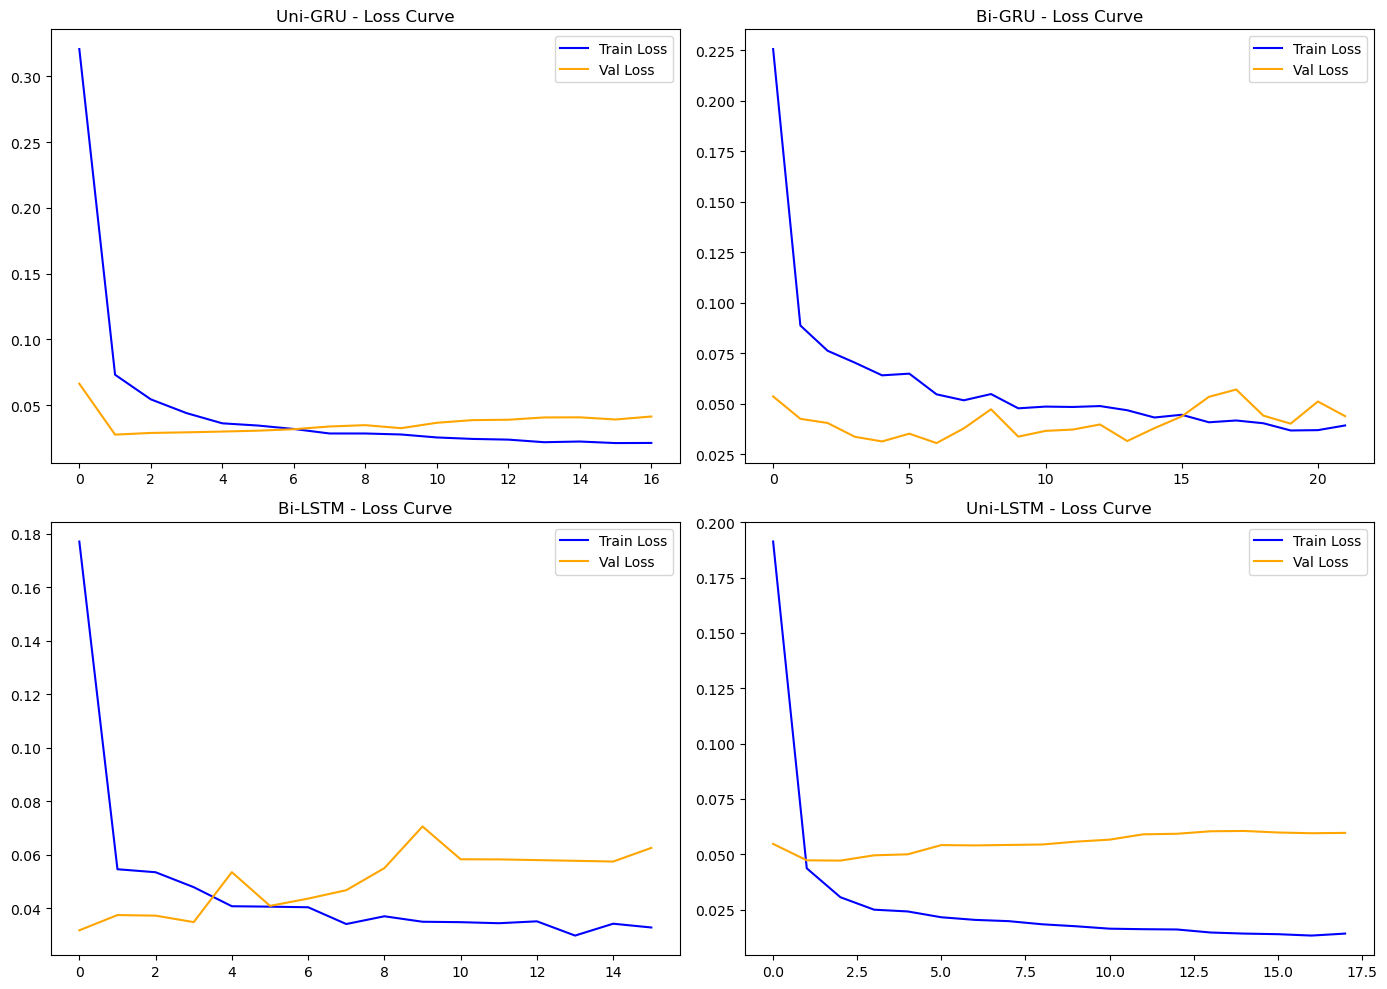

In [21]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
axes = axes.flatten()

histories = {'Uni-GRU': history_uni_gru, 'Bi-GRU': history_bi_gru, 'Bi-LSTM': history_bi_lstm, 'Uni-LSTM': history_uni_lstm}

for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['loss'], label = 'Train Loss', color = 'blue')
    ax.plot(hist.history['val_loss'], label = 'Val Loss', color = 'orange')
    ax.set_title(f'{name} - Loss Curve')
    ax.legend()
    
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'loss_curves.png'), dpi = 150, bbox_inches = 'tight')
plt.show()

### R2,RMSE & MAE COMAPRISON

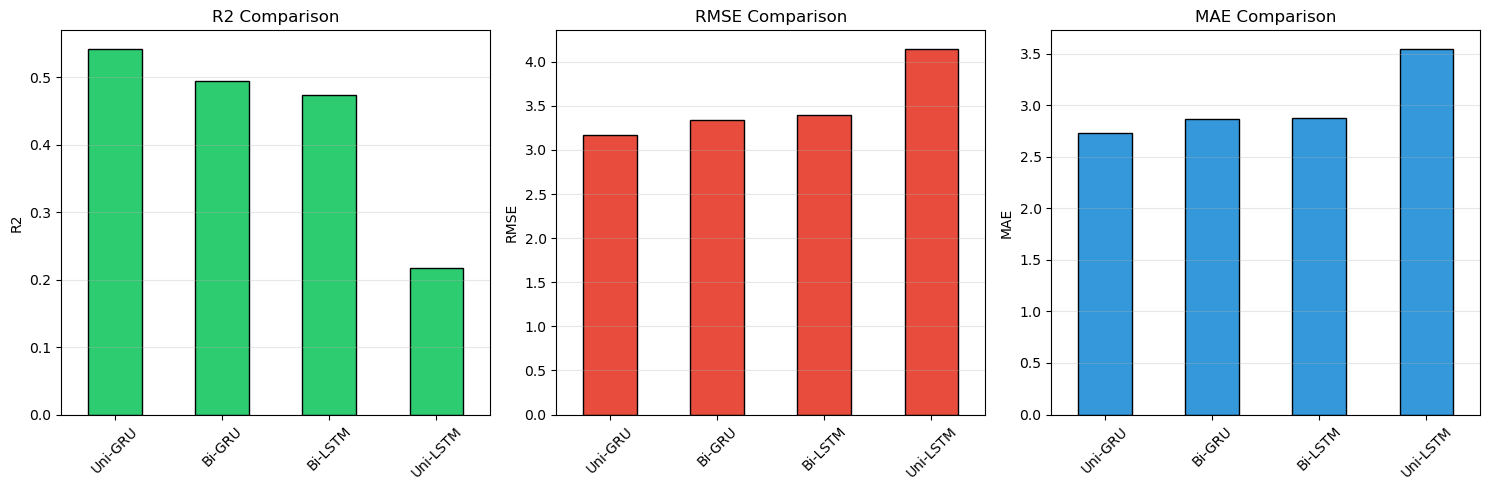

In [22]:
metrics_df = pd.DataFrame({
    name: {
        'R2': res['r2'],
        'RMSE': res['rmse'],
        'MAE': res['mae'],
    }
    for name, res in results.items()
}).T

fig, axes = plt.subplots(1, 3, figsize = (15, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db']

for ax, metric, color in zip(axes, ['R2', 'RMSE', 'MAE'], colors):
    metrics_df[metric].plot(kind = 'bar', ax = ax, color = color, edgecolor = 'black')
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.tick_params(axis = 'x', rotation = 45)
    ax.grid(True, alpha = 0.3, axis = 'y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'metrics_comparison.png'), dpi = 150, bbox_inches = 'tight')
plt.show()

In [23]:
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

summary = pd.DataFrame({
    'Model': list(results.keys()),
    'R²': [f"{r['r2']:.4f}" for r in results.values()],
    'RMSE ($)': [f"{r['rmse']:.2f}" for r in results.values()],
    'MAE ($)': [f"{r['mae']:.2f}" for r in results.values()],
    'MSE ($²)': [f"{r['mse']:.2f}" for r in results.values()],
})

print(summary.to_string(index=False))
print("="*60)


FINAL RESULTS SUMMARY
   Model     R² RMSE ($) MAE ($) MSE ($²)
 Uni-GRU 0.5426     3.17    2.73    10.06
  Bi-GRU 0.4940     3.34    2.87    11.13
 Bi-LSTM 0.4742     3.40    2.88    11.57
Uni-LSTM 0.2174     4.15    3.55    17.22


In [24]:
model_uni_gru.save(os.path.join(MODEL_SAVE_PATH, 'model_uni_gru.h5'))
model_bi_gru.save(os.path.join(MODEL_SAVE_PATH, 'model_bi_gru.h5'))
model_bi_lstm.save(os.path.join(MODEL_SAVE_PATH, 'model_bi_lstm.h5'))
model_uni_lstm.save(os.path.join(MODEL_SAVE_PATH, 'model_uni_lstm.h5'))

print(f"4 model .h5 files saved to {MODEL_SAVE_PATH}")

4 model .h5 files saved to d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\models


### TRAINING HISTORIES

In [25]:
histories = {
    'uni_gru':  history_uni_gru.history,
    'bi_gru':   history_bi_gru.history,
    'bi_lstm':  history_bi_lstm.history,
    'uni_lstm': history_uni_lstm.history,
}

for name, hist in histories.items():
    save_path = os.path.join(OUTPUT_PATH, f'history_{name}.json')
    with open(save_path, 'w') as f:
        json.dump(hist, f, indent=2)

print(f"4 history .json files saved to {OUTPUT_PATH}")

4 history .json files saved to d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\results


### SAVING RESULTS IN CSV

In [26]:
results_df = pd.DataFrame({
    'Model': ['Uni-GRU', 'Bi-GRU', 'Bi-LSTM', 'Uni-LSTM'],
    'R2': [results['Uni-GRU']['r2'], results['Bi-GRU']['r2'],
           results['Bi-LSTM']['r2'], results['Uni-LSTM']['r2']],
    'RMSE': [results['Uni-GRU']['rmse'], results['Bi-GRU']['rmse'],
             results['Bi-LSTM']['rmse'], results['Uni-LSTM']['rmse']],
    'MAE': [results['Uni-GRU']['mae'], results['Bi-GRU']['mae'],
            results['Bi-LSTM']['mae'], results['Uni-LSTM']['mae']],
    'MSE': [results['Uni-GRU']['mse'], results['Bi-GRU']['mse'],
            results['Bi-LSTM']['mse'], results['Uni-LSTM']['mse']],
})

results_df.to_csv(os.path.join(OUTPUT_PATH, 'model_result.csv'), index=False)
print(f"model_result.csv saved to {OUTPUT_PATH}")

model_result.csv saved to d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\results
